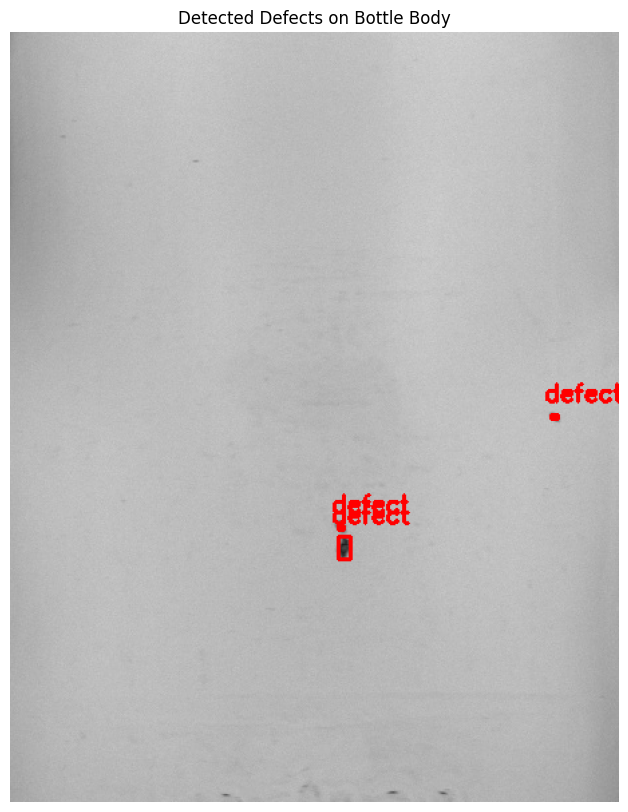

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the image
folder_path = r'C:\Users\jinny\Desktop\cv\image\32022-07-18-01-25-27.jpg'
image = cv2.imread(folder_path)

# 2. Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# 3. Crop the image to isolate the bottle body (ROI)
h, w = gray.shape
y1, y2 = int(h * 0.45), int(h * 0.93)
x1, x2 = int(w * 0.15), int(w * 0.80)

crop_gray = gray[y1:y2, x1:x2]
crop_color = image[y1:y2, x1:x2].copy()

# 4. Thresholding to isolate defects
_, thresh = cv2.threshold(crop_gray, 100, 255, cv2.THRESH_BINARY_INV)

# 5. Find contours and Draw "defect" rectangle
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

for cnt in contours:
    area = cv2.contourArea(cnt)
    if 2 < area < 500: 
        x, y, w_rect, h_rect = cv2.boundingRect(cnt)
        
        cv2.rectangle(crop_color, (x, y), (x + w_rect, y + h_rect), (0, 0, 255), 2)
        
        cv2.putText(crop_color, 'defect', (x - 5, y - 10), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)

# 6. Display the final result
plt.figure(figsize=(8, 10))
plt.imshow(cv2.cvtColor(crop_color, cv2.COLOR_BGR2RGB))
plt.title("Detected Defects on Bottle Body")
plt.axis('off')
plt.show()